Collisions: (503475, 44)
Vehicles: (920692, 32)
Casualties: (640522, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503475 entries, 0 to 503474
Data columns (total 44 columns):
 #   Column                                            Non-Null Count   Dtype  
---  ------                                            --------------   -----  
 0   collision_index                                   503475 non-null  object 
 1   collision_year                                    503475 non-null  int64  
 2   collision_ref_no                                  503475 non-null  object 
 3   location_easting_osgr                             503410 non-null  float64
 4   location_northing_osgr                            503410 non-null  float64
 5   longitude                                         503410 non-null  float64
 6   latitude                                          503410 non-null  float64
 7   police_force                                      503475 non-null  int64  
 8   collision_s

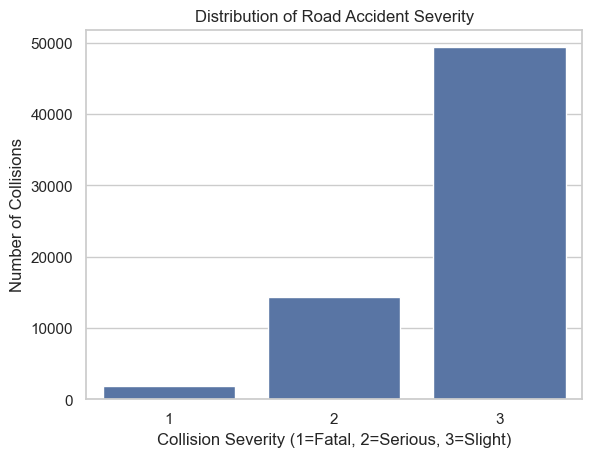

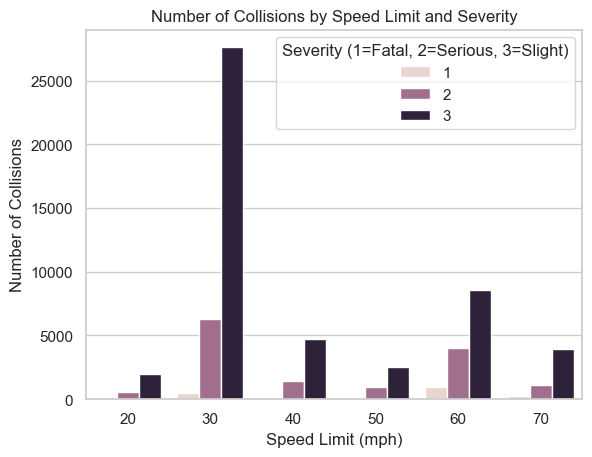

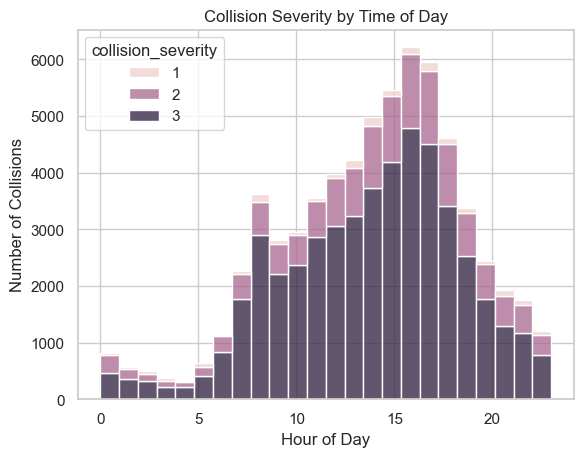

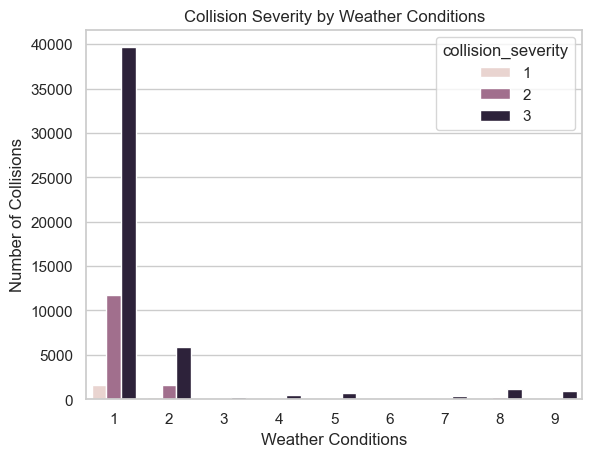

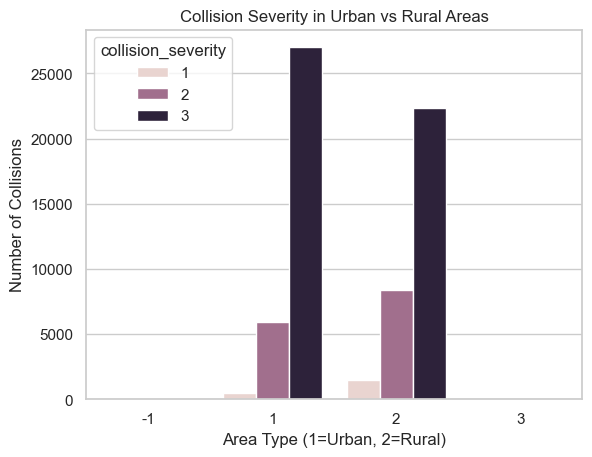

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

collisions = pd.read_csv(
    r"C:\Users\USER\Desktop\Project\dft-road-casualty-statistics-collision-last-5-years.gz",
    compression="gzip"
)

vehicles = pd.read_csv(
    r"C:\Users\USER\Desktop\Project\dft-road-casualty-statistics-vehicle-last-5-years.gz",
    compression="gzip",
    low_memory=False
)

casualties = pd.read_csv(
    r"C:\Users\USER\Desktop\Project\dft-road-casualty-statistics-casualty-last-5-years.gz",
    compression="gzip"
)

print("Collisions:", collisions.shape)
print("Vehicles:", vehicles.shape)
print("Casualties:", casualties.shape)

collisions.info()
vehicles.info()
casualties.info()

collision_vehicle = pd.merge(
    collisions,
    vehicles,
    on="collision_index",
    how="inner"
)

full_data = pd.merge(
    collision_vehicle,
    casualties,
    on="collision_index",
    how="inner"
)

print("Merged dataset:", full_data.shape)

data = full_data[
    [
        'collision_severity',
        'day_of_week',
        'time',
        'weather_conditions',
        'road_type',
        'speed_limit',
        'light_conditions',
        'urban_or_rural_area',
        'age_of_driver',
        'sex_of_driver'
    ]
]

data = data.dropna()

data['hour'] = pd.to_datetime(
    data['time'], format='%H:%M', errors='coerce'
).dt.hour

data = data.dropna(subset=['hour'])

data.info()

print(data['collision_severity'].value_counts())

#Plot 1 
sns.countplot(x='collision_severity', data=data)
plt.title("Distribution of Road Accident Severity")
plt.xlabel("Collision Severity (1=Fatal, 2=Serious, 3=Slight)")
plt.ylabel("Number of Collisions")
plt.show()

#Plot 2
sns.countplot(x='speed_limit', hue='collision_severity', data=data)
plt.title("Number of Collisions by Speed Limit and Severity")
plt.xlabel("Speed Limit (mph)")
plt.ylabel("Number of Collisions")
plt.legend(title="Severity (1=Fatal, 2=Serious, 3=Slight)")
plt.show()

#plot 3
sns.histplot(data=data, x='hour', hue='collision_severity', bins=24, multiple='stack')
plt.title("Collision Severity by Time of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Collisions")
plt.show()

#Plot 4
sns.countplot(x='weather_conditions', hue='collision_severity', data=data)
plt.title("Collision Severity by Weather Conditions")
plt.xlabel("Weather Conditions")
plt.ylabel("Number of Collisions")
plt.show()

#Plot 5
sns.countplot(x='urban_or_rural_area', hue='collision_severity', data=data)
plt.title("Collision Severity in Urban vs Rural Areas")
plt.xlabel("Area Type (1=Urban, 2=Rural)")
plt.ylabel("Number of Collisions")
plt.show()
